## **Fase 4 - Simulación Monte Carlo del Mundial 2026**

Esta fase aplica el modelo seleccionado en la Fase 3 a su propósito práctico:
estimar, mediante simulación Monte Carlo, las probabilidades de que cada selección
alcance cada fase del Mundial 2026, e identificar favoritos y posibles sorpresas.
El resultado alimenta directamente la quiniela.

El modelo usado es Dixon-Coles (1997), el de mejor desempeño en la validación
temporal de la Fase 3. Se ajusta una vez sobre toda la ventana de datos disponible
(2002 a marzo de 2026) y se usa para generar los marcadores de un torneo completo,
repetido un número grande de veces. La estructura del torneo (12 grupos de 4, ronda
de 32, jerarquía de desempates) sigue el reglamento oficial descrito en el documento
*Formato del Mundial 2026*.

Limitación principal, declarada desde el inicio: el Mundial 2026 estrena formato
(48 equipos, tres países sede) y el modelo se entrena con datos de mundiales de 32
equipos y de partidos en sedes diversas. La comparabilidad estructural es imperfecta;
las probabilidades de esta fase deben leerse como estimaciones informadas, no como
certezas.

---
## 1. Imports y configuración

Semilla global 42. El generador aleatorio de numpy (`default_rng`) se inicializa
con esa semilla, de modo que la simulación es reproducible bit a bit.

In [1]:
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import minimize
from scipy.stats import poisson

warnings.filterwarnings("ignore")

SEED = 42
RAW_DIR  = Path("datos")       # datos fuente (results.csv, shootouts.csv, etc.)
OUT_DIR  = Path("resultados")  # CSVs generados entre fases
FIGS_DIR = Path("figuras")     # figuras para LaTeX
OUT_DIR.mkdir(exist_ok=True); FIGS_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 170)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

print("Entorno listo. Semilla =", SEED)

Entorno listo. Semilla = 42


---
## 2. Modelo final Dixon-Coles

A diferencia de la Fase 3, donde Dixon-Coles se ajustaba cuatro veces (una por
pliegue de validación), aquí se ajusta una sola vez con todos los datos
disponibles, de 2002 a marzo de 2026. Este es el modelo de producción: se usa
toda la información para estimar la fuerza actual de cada selección.

Decisiones que se mantienen de la Fase 3:

- Ponderación temporal con vida media de dos años (`HALF_LIFE`). Los partidos de
  los ciclos recientes, incluidos los de clasificación a 2026, pesan más que los
  antiguos. La fecha de referencia es el inicio del torneo (11 de junio de 2026).
- Corrección de marcadores bajos mediante el parámetro rho.
- Estimación por máxima verosimilitud ponderada con gradiente analítico.
- Agrupación de equipos con menos de `MIN_MATCHES` partidos en la categoría
  `Other`. Como se verifica en la sección 3, ninguno de los 48 participantes cae
  en esa categoría.

Una diferencia respecto al código de la Fase 3: aquí se utiliza la columna
`home_team_norm` en lugar de `home_team` para identificar a los equipos, de modo
que los parámetros del modelo estén etiquetados con los mismos nombres normalizados
que usa el diccionario `GRUPOS` (por ejemplo, `USA` en lugar de `United States`).
Para los equipos cuyo nombre no difiere, el ajuste es idéntico al de la Fase 3.

In [2]:
HALF_LIFE = 730                       # vida media de la ponderación temporal (días)
MIN_MATCHES = 10                      # umbral de agrupación en "Other"
REF_DATE = pd.Timestamp("2026-06-11") # inicio del Mundial 2026

datos = pd.read_csv(OUT_DIR / "data_features.csv", parse_dates=["date"])
print(f"Partidos disponibles: {len(datos):,} "
      f"({datos['date'].min().date()} a {datos['date'].max().date()})")

def agrupar_raros(df):
    cnt = pd.concat([df["home_team_norm"], df["away_team_norm"]]).value_counts()
    raros = set(cnt[cnt < MIN_MATCHES].index)
    d = df.copy()
    for c in ("home_team_norm", "away_team_norm"):
        d[c] = d[c].where(~d[c].isin(raros), "Other")
    return d, raros

def dc_fit(df, ref_date):
    d, raros = agrupar_raros(df)
    equipos = sorted(set(d["home_team_norm"]) | set(d["away_team_norm"]))
    n = len(equipos)
    idx = {t: i for i, t in enumerate(equipos)}
    hi = d["home_team_norm"].map(idx).values
    ai = d["away_team_norm"].map(idx).values
    x = d["home_score"].values.astype(float)
    y = d["away_score"].values.astype(float)
    home = (~d["neutral"]).astype(float).values
    w = np.exp(-(np.log(2) / HALF_LIFE) * (ref_date - d["date"]).dt.days.values)
    bajos = (x <= 1) & (y <= 1)
    m00 = bajos & (x == 0) & (y == 0)
    m01 = bajos & (x == 0) & (y == 1)
    m10 = bajos & (x == 1) & (y == 0)
    m11 = bajos & (x == 1) & (y == 1)

    def unpack(p):
        atk = np.concatenate([[0.0], p[:n - 1]])
        dfn = np.concatenate([[0.0], p[n - 1:2 * n - 2]])
        return atk, dfn, p[2 * n - 2], p[2 * n - 1], p[2 * n]

    def negll(p):
        atk, dfn, c, g, rho = unpack(p)
        ll_lam = c + atk[hi] + dfn[ai] + g * home
        ll_mu = c + atk[ai] + dfn[hi]
        lam, mu = np.exp(ll_lam), np.exp(ll_mu)
        pois = x * ll_lam - lam + y * ll_mu - mu
        tau = np.ones(len(lam))
        tau[m00] = 1 - lam[m00] * mu[m00] * rho
        tau[m01] = 1 + lam[m01] * rho
        tau[m10] = 1 + mu[m10] * rho
        tau[m11] = 1 - rho
        if np.any(tau <= 1e-10):
            return 1e10
        return -np.sum(w * (pois + np.log(tau)))

    def grad(p):
        atk, dfn, c, g, rho = unpack(p)
        ll_lam = c + atk[hi] + dfn[ai] + g * home
        ll_mu = c + atk[ai] + dfn[hi]
        lam, mu = np.exp(ll_lam), np.exp(ll_mu)
        g_lam = x - lam
        g_mu = y - mu
        g_rho = np.zeros(len(lam))
        tau = np.ones(len(lam))
        tau[m00] = 1 - lam[m00] * mu[m00] * rho
        tau[m01] = 1 + lam[m01] * rho
        tau[m10] = 1 + mu[m10] * rho
        tau[m11] = 1 - rho
        d_lam = np.zeros(len(lam))
        d_mu = np.zeros(len(lam))
        lm = lam * mu
        d_lam[m00] += -lm[m00] * rho / tau[m00]
        d_mu[m00] += -lm[m00] * rho / tau[m00]
        g_rho[m00] += -lm[m00] / tau[m00]
        d_lam[m01] += lam[m01] * rho / tau[m01]
        g_rho[m01] += lam[m01] / tau[m01]
        d_mu[m10] += mu[m10] * rho / tau[m10]
        g_rho[m10] += mu[m10] / tau[m10]
        g_rho[m11] += -1.0 / tau[m11]
        g_lam = w * (g_lam + d_lam)
        g_mu = w * (g_mu + d_mu)
        g_atk = np.bincount(hi, g_lam, n) + np.bincount(ai, g_mu, n)
        g_dfn = np.bincount(ai, g_lam, n) + np.bincount(hi, g_mu, n)
        g_c = g_lam.sum() + g_mu.sum()
        g_g = (g_lam * home).sum()
        g_r = (w * g_rho).sum()
        return -np.concatenate([g_atk[1:], g_dfn[1:], [g_c, g_g, g_r]])

    p0 = np.zeros(2 * n + 1)
    p0[2 * n - 1] = 0.3
    limites = [(-3, 3)] * (2 * n - 2) + [(-2, 2), (-1, 1), (-0.2, 0.2)]
    res = minimize(negll, p0, jac=grad, method="L-BFGS-B", bounds=limites,
                   options={"maxiter": 5000, "ftol": 1e-10, "gtol": 1e-6})
    atk, dfn, c, g, rho = unpack(res.x)
    ma, md_ = atk.mean(), dfn.mean()
    return {"intercept": c + ma + md_, "gamma": g, "rho": rho,
            "atk": {t: atk[idx[t]] - ma for t in equipos},
            "dfn": {t: dfn[idx[t]] - md_ for t in equipos},
            "raros": raros, "converge": res.success}

modelo = dc_fit(datos, REF_DATE)
print(f"Modelo final ajustado. Convergencia: {modelo['converge']}")
print(f"  intercepto = {modelo['intercept']:.3f}, gamma = {modelo['gamma']:.3f}, "
      f"rho = {modelo['rho']:.4f}")

Partidos disponibles: 23,086 (2002-01-04 a 2026-03-31)
Modelo final ajustado. Convergencia: True
  intercepto = 0.109, gamma = 0.230, rho = -0.0525


---
## 3. El Mundial 2026: equipos, grupos y formato

Los 48 participantes y los 12 grupos corresponden al sorteo final del 5 de
diciembre de 2025 y a los seis cupos resueltos en los repechajes del 31 de marzo
de 2026 (ganadores: Bosnia y Herzegovina, Suecia, Turquía y Chequia por la vía
europea; RD Congo e Irak por el repechaje intercontinental).

Los nombres de las selecciones se mapean a la nomenclatura del dataset histórico
(la columna normalizada de la Fase 1). Algunos difieren: Estados Unidos figura
como USA, Corea del Sur como Korea Republic, Irán como IR Iran, Costa de Marfil
como Cote d'Ivoire, Cabo Verde como Cabo Verde y RD Congo como Congo DR. El
código verifica que los 48 equipos existan en los datos y tengan parámetro propio
en el modelo.

In [3]:
GRUPOS = {
    "A": ["Mexico", "South Africa", "Korea Republic", "Czechia"],
    "B": ["Canada", "Bosnia and Herzegovina", "Qatar", "Switzerland"],
    "C": ["Brazil", "Morocco", "Haiti", "Scotland"],
    "D": ["USA", "Paraguay", "Australia", "Turkey"],
    "E": ["Germany", "Curacao", "Côte d'Ivoire", "Ecuador"],
    "F": ["Netherlands", "Japan", "Sweden", "Tunisia"],
    "G": ["Belgium", "Egypt", "IR Iran", "New Zealand"],
    "H": ["Spain", "Cabo Verde", "Saudi Arabia", "Uruguay"],
    "I": ["France", "Senegal", "Iraq", "Norway"],
    "J": ["Argentina", "Algeria", "Austria", "Jordan"],
    "K": ["Portugal", "Congo DR", "Uzbekistan", "Colombia"],
    "L": ["England", "Croatia", "Ghana", "Panama"],
}

equipos48 = [t for g in GRUPOS.values() for t in g]
assert len(equipos48) == 48 and len(set(equipos48)) == 48, "deben ser 48 únicos"

faltan_datos = [t for t in equipos48
                if t not in set(datos["home_team_norm"]) | set(datos["away_team_norm"])]
faltan_modelo = [t for t in equipos48 if t not in modelo["atk"]]
agrupados = [t for t in equipos48 if t in modelo["raros"]]
print(f"Equipos sin historial en datos : {faltan_datos or 'ninguno'}")
print(f"Equipos sin parámetro de modelo: {faltan_modelo or 'ninguno'}")
print(f"Equipos agrupados en 'Other'   : {agrupados or 'ninguno'}")
print("Los 48 participantes tienen rating individual.")

Equipos sin historial en datos : ninguno
Equipos sin parámetro de modelo: ninguno
Equipos agrupados en 'Other'   : ninguno
Los 48 participantes tienen rating individual.


### 3.1 Fuerza estimada de los participantes

Una primera lectura de cordura: la fuerza neta de cada selección según el modelo,
definida como la suma del parámetro de ataque y el negativo del de defensa (un
valor alto indica un equipo que anota mucho y recibe poco). No es una predicción
del torneo, solo una verificación de que el modelo ordena a los equipos de forma
plausible antes de simular.

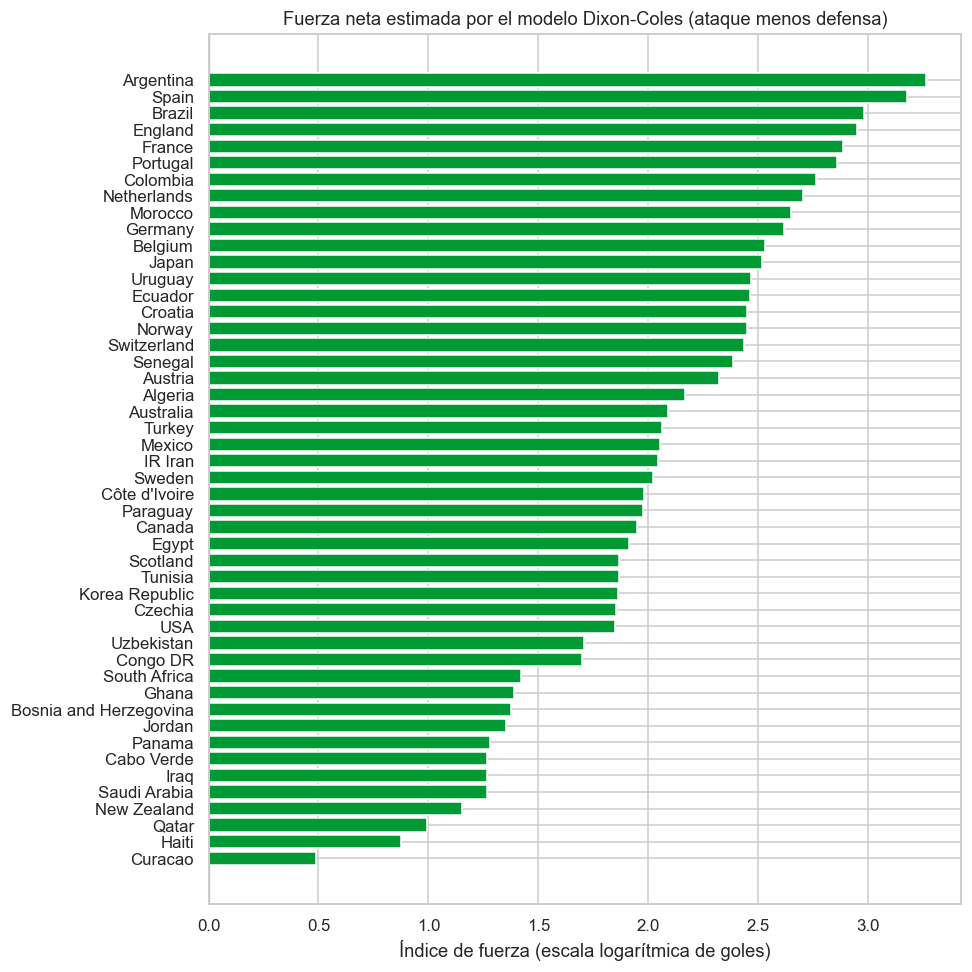

In [4]:
fuerza = pd.Series({t: modelo["atk"][t] - modelo["dfn"][t] for t in equipos48})
fuerza = fuerza.sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 9))
colores = ["#093" if v > 0 else "#b33" for v in fuerza.values]
ax.barh(fuerza.index[::-1], fuerza.values[::-1], color=colores[::-1])
ax.axvline(0, color="grey", lw=0.8)
ax.set_title("Fuerza neta estimada por el modelo Dixon-Coles (ataque menos defensa)")
ax.set_xlabel("Índice de fuerza (escala logarítmica de goles)")
plt.tight_layout()
plt.savefig(FIGS_DIR / "fig7_fuerza.pdf", bbox_inches="tight", dpi=150)
plt.show()

---
## 4. Submodelo de tanda de penales

En las rondas de eliminación, un partido empatado tras los 90 minutos va a
prórroga y, de persistir el empate, a una tanda de penales. El modelo de goles no
predice tandas, así que se necesita un tratamiento explícito. El dataset
`shootouts.csv` permite calibrarlo con datos reales.

Decisión metodológica. Se cruzan las 675 tandas históricas con el ranking FIFA de
ambos equipos a la fecha del partido y se mide con qué frecuencia gana la tanda el
equipo mejor clasificado. El resultado, mostrado abajo, es revelador: el favorito
gana la tanda solo alrededor del 55 por ciento de las veces, y la ventaja de
patear primero es menor todavía (cerca del 52 por ciento). Es decir, una tanda de
penales es casi un volado, con una inclinación leve hacia el equipo más fuerte.

En consecuencia, el submodelo es deliberadamente simple y está calibrado con ese
dato: cuando un partido de eliminación llega a penales, lo gana el equipo favorito
(el de mayor probabilidad de victoria en los 90 minutos según el modelo) con
probabilidad 0.55, y el otro con 0.45. Un submodelo más elaborado no se justifica:
la propia evidencia muestra que la tanda es un proceso de alta varianza, casi
aleatorio. Tratarlo así es la lectura honesta de los datos.

In [5]:
shootouts = pd.read_csv(RAW_DIR / "shootouts.csv", parse_dates=["date"])
clave = datos[["date", "home_team", "away_team",
               "home_fifa_rank", "away_fifa_rank"]]
sh = (shootouts.merge(clave, on=["date", "home_team", "away_team"], how="inner")
               .dropna(subset=["home_fifa_rank", "away_fifa_rank"]))
sh = sh[sh["winner"].isin(sh["home_team"]) | sh["winner"].isin(sh["away_team"])]
local_mejor = sh["home_fifa_rank"] < sh["away_fifa_rank"]
gana_favorito = ((local_mejor & (sh["winner"] == sh["home_team"]))
                 | (~local_mejor & (sh["winner"] == sh["away_team"]))).mean()
print(f"Tandas históricas con ranking de ambos equipos: {len(sh)}")
print(f"El equipo mejor clasificado gana la tanda: {gana_favorito:.3f}")
print("Calibración del submodelo: el favorito gana la tanda con probabilidad 0.55.")

PROB_FAVORITO_PENALES = 0.55

Tandas históricas con ranking de ambos equipos: 315
El equipo mejor clasificado gana la tanda: 0.546
Calibración del submodelo: el favorito gana la tanda con probabilidad 0.55.


---
## 5. Motor de simulación

### 5.1 Matrices de marcador precomputadas

Para cada par ordenado de selecciones se construye una vez la distribución
conjunta de marcadores que predice el modelo: una matriz de 11 por 11 (goles de 0
a 10 por equipo) con la corrección Dixon-Coles aplicada a las cuatro celdas de
marcador bajo. Simular un partido se reduce entonces a muestrear una celda de esa
matriz. Precomputar las 2.256 matrices (48 por 47 pares) hace que cada simulación
de torneo cueste una fracción de milisegundo.

Decisión: todos los partidos se simulan en cancha neutral (sin el término de
ventaja de local del modelo). El Mundial 2026 se juega mayoritariamente en sedes
neutrales para casi todas las selecciones; asignar ventaja partido a partido
exigiría el calendario de sedes y excede el alcance. Es una simplificación que
penaliza levemente a los tres anfitriones (México, Canadá y Estados Unidos), y se
declara como tal.

### 5.2 Prórroga

Si un partido de eliminación termina empatado, se simulan 30 minutos de prórroga
como un tercio de partido: los goles adicionales se muestrean de una distribución
de Poisson con las tasas del modelo escaladas por 1/3. La corrección de marcadores
bajos se mantiene. Si tras la prórroga el empate persiste, se aplica el submodelo
de penales de la sección 4.

In [6]:
MAXG = 10
IDX = {t: i for i, t in enumerate(equipos48)}

def matriz_marcador(a, b, escala=1.0):
    '''Distribución conjunta de marcadores (Dixon-Coles, cancha neutral).'''
    lam = np.exp(modelo["intercept"] + modelo["atk"][a] + modelo["dfn"][b]) * escala
    mu = np.exp(modelo["intercept"] + modelo["atk"][b] + modelo["dfn"][a]) * escala
    pa = poisson.pmf(np.arange(MAXG + 1), lam)
    pb = poisson.pmf(np.arange(MAXG + 1), mu)
    M = np.outer(pa, pb)
    rho = modelo["rho"]
    M[0, 0] *= 1 - lam * mu * rho
    M[0, 1] *= 1 + lam * rho
    M[1, 0] *= 1 + mu * rho
    M[1, 1] *= 1 - rho
    M = np.clip(M, 0, None)
    return M / M.sum()

# CDF planas para muestreo por transformada inversa.
CDF_REG = np.zeros((48, 48, (MAXG + 1) ** 2))
CDF_EXT = np.zeros_like(CDF_REG)
FAVORITO = np.zeros((48, 48), dtype=bool)   # True si A es favorito sobre B
for i, a in enumerate(equipos48):
    for j, b in enumerate(equipos48):
        if i == j:
            continue
        M = matriz_marcador(a, b)
        CDF_REG[i, j] = np.cumsum(M.ravel())
        CDF_EXT[i, j] = np.cumsum(matriz_marcador(a, b, escala=1 / 3).ravel())
        FAVORITO[i, j] = np.tril(M, -1).sum() >= np.triu(M, 1).sum()

GOLES_LOCAL = np.repeat(np.arange(MAXG + 1), MAXG + 1)
GOLES_VISITA = np.tile(np.arange(MAXG + 1), MAXG + 1)
print(f"Precomputadas {48 * 47} matrices de marcador (regulación y prórroga).")

Precomputadas 2256 matrices de marcador (regulación y prórroga).


### 5.3 Ranking FIFA para el desempate final

La jerarquía de desempates termina, como último recurso, en el ranking FIFA. Se
recupera el ranking más reciente de cada participante a partir del dataset de la
Fase 1.

In [7]:
ranking_fifa = {}
for t in equipos48:
    sub = datos[(datos["home_team_norm"] == t) | (datos["away_team_norm"] == t)]
    ult = sub.sort_values("date").iloc[-1]
    ranking_fifa[t] = (ult["home_fifa_rank"] if ult["home_team_norm"] == t
                       else ult["away_fifa_rank"])
assert all(not pd.isna(v) for v in ranking_fifa.values())
print("Ranking FIFA recuperado para los 48 participantes.")

Ranking FIFA recuperado para los 48 participantes.


### 5.4 Asignación de los mejores terceros al cuadro

En el formato de 2026 avanzan a la ronda de 32 los 12 primeros, los 12 segundos y
los 8 mejores terceros. Cada uno de los 8 terceros enfrenta al ganador de un grupo,
y la asignación depende de cuáles 12 grupos producen a esos 8 terceros. FIFA
publica una tabla de consulta con las 495 combinaciones posibles, C(12,8).

Decisión: en lugar de transcribir la tabla oficial de FIFA, se reconstruye su
lógica. Cada ganador de grupo tiene asignado un conjunto de 5 grupos de los que
puede provenir su rival tercero (sin que un tercero enfrente al ganador de su
propio grupo). Para cada uno de los 495 escenarios se resuelve el emparejamiento
válido entre los 8 grupos clasificados y las 8 posiciones del cuadro. Cuando un
escenario admite más de un emparejamiento válido, se toma uno de forma
determinista. Esta es una simplificación respecto de la elección exacta de FIFA;
sobre 20.000 simulaciones con resultados de grupo aleatorios, no afecta de forma
material a las probabilidades agregadas por fase. Los 495 escenarios se resuelven
una sola vez y se guardan en una tabla de consulta.

In [8]:
# Cada ganador de grupo (slot) y su grupo de 5 orígenes posibles de tercero.
CLUSTER = {
    "E": set("ABCDF"), "I": set("CDFGH"), "A": set("CEFHI"), "L": set("EHIJK"),
    "D": set("BEFIJ"), "G": set("AEHIJ"), "B": set("EFGIJ"), "K": set("DEIJL"),
}
SLOTS_TERCERO = list(CLUSTER.keys())

def resolver_matching(grupos_clasificados):
    '''Empareja los 8 grupos clasificados con los 8 slots respetando los clusters.'''
    asignacion = {}
    usados = set()
    def backtrack(k):
        if k == len(SLOTS_TERCERO):
            return True
        s = SLOTS_TERCERO[k]
        for grupo in sorted((CLUSTER[s] & set(grupos_clasificados)) - usados):
            asignacion[s] = grupo
            usados.add(grupo)
            if backtrack(k + 1):
                return True
            usados.discard(grupo)
            del asignacion[s]
        return False
    return dict(asignacion) if backtrack(0) else None

TABLA_TERCEROS = {}
for combo in combinations("ABCDEFGHIJKL", 8):
    m = resolver_matching(combo)
    if m is not None:
        TABLA_TERCEROS[frozenset(combo)] = m
print(f"Escenarios de terceros resueltos: {len(TABLA_TERCEROS)} de 495 posibles.")

Escenarios de terceros resueltos: 495 de 495 posibles.


---
## 6. Clasificación de grupos con la jerarquía de desempates

La función de ordenamiento de un grupo implementa la jerarquía completa del
reglamento 2026. El punto que la distingue de ediciones anteriores: la prioridad
inicial es el enfrentamiento directo, no la diferencia de goles general.

Orden de aplicación: (1) puntos; (2) entre equipos empatados en puntos, se abre
un sub-bloque con puntos del enfrentamiento directo, luego diferencia de goles
directa y goles a favor directos; (3) si el empate persiste, diferencia de goles
general y goles a favor general; (4) como último recurso, ranking FIFA.

El criterio de Fair Play (puntos por tarjetas) se omite: el modelo de goles no
predice tarjetas. Es el supuesto declarado en el Marco Metodológico. En la
práctica el Fair Play decide un grupo en contadísimas ocasiones, y sustituirlo por
el ranking FIFA como penúltimo criterio no altera de forma apreciable el resultado.

In [9]:
# Calendario round-robin de un grupo de 4 (índices locales 0..3).
ROUND_ROBIN = [(0, 1), (2, 3), (0, 2), (1, 3), (0, 3), (1, 2)]

def clasificar_grupo(nombres, G):
    '''Ordena los 4 equipos de un grupo. G[i][j] = goles del equipo i ante j.'''
    pts = np.zeros(4); gf = np.zeros(4); ga = np.zeros(4)
    for i in range(4):
        for j in range(4):
            if i == j:
                continue
            gi, gj = G[i][j], G[j][i]
            gf[i] += gi; ga[i] += gj
            if gi > gj:
                pts[i] += 3
            elif gi == gj:
                pts[i] += 1
    gd = gf - ga
    orden = sorted(range(4), key=lambda i: (pts[i], gd[i], gf[i]), reverse=True)
    # Resolver bloques empatados en puntos con enfrentamiento directo.
    final = []
    k = 0
    while k < 4:
        bloque = [orden[k]]
        while k + 1 < 4 and pts[orden[k + 1]] == pts[bloque[0]]:
            k += 1
            bloque.append(orden[k])
        k += 1
        if len(bloque) > 1:
            hp = {i: 0 for i in bloque}
            hgd = {i: 0 for i in bloque}
            hgf = {i: 0 for i in bloque}
            for i in bloque:
                for j in bloque:
                    if i == j:
                        continue
                    gi, gj = G[i][j], G[j][i]
                    hgf[i] += gi
                    hgd[i] += gi - gj
                    if gi > gj:
                        hp[i] += 3
                    elif gi == gj:
                        hp[i] += 1
            bloque.sort(key=lambda i: (hp[i], hgd[i], hgf[i], gd[i], gf[i],
                                       -ranking_fifa[nombres[i]]), reverse=True)
        final += bloque
    return final

---
## 7. La simulación de un torneo completo

Una simulación ejecuta el torneo entero: los 72 partidos de grupos, el ranking de
los 12 grupos, la selección y ordenamiento de los 8 mejores terceros, la
construcción de la ronda de 32 según el cuadro oficial, y las cinco rondas de
eliminación hasta la final.

El cuadro de eliminatorias reproduce la estructura oficial publicada por FIFA: los
16 partidos de la ronda de 32 (incluido que el ganador de cada grupo enfrenta a un
tercero de su cluster), y el árbol que conecta ronda de 32, octavos, cuartos,
semifinales y final, con sus dos mitades separadas.

Para cada simulación se registra la fase más avanzada que alcanza cada selección,
codificada de 0 (eliminado en grupos) a 6 (campeón).

In [10]:
# Cuadro oficial: índices 0..15 corresponden a los partidos 73..88 de la ronda de 32.
# R32[k] sera una tupla (idx_equipo_A, idx_equipo_B) construida en cada simulacion.
# Arbol de eliminatorias sobre esos indices:
R16_PARES = [(1, 4), (0, 2), (3, 5), (6, 7),
             (10, 11), (8, 9), (13, 15), (12, 14)]   # partidos 89..96
QF_PARES = [(0, 1), (4, 5), (2, 3), (6, 7)]           # partidos 97..100
SF_PARES = [(0, 1), (2, 3)]                           # partidos 101..102

def jugar_eliminacion(a, b, rng):
    '''Devuelve el índice del ganador de un partido de eliminación directa.'''
    c = int(np.searchsorted(CDF_REG[a, b], rng.random()))
    gl, gv = GOLES_LOCAL[c], GOLES_VISITA[c]
    if gl > gv:
        return a
    if gv > gl:
        return b
    # prorroga
    c = int(np.searchsorted(CDF_EXT[a, b], rng.random()))
    if GOLES_LOCAL[c] > GOLES_VISITA[c]:
        return a
    if GOLES_VISITA[c] > GOLES_LOCAL[c]:
        return b
    # tanda de penales
    favorito = a if FAVORITO[a, b] else b
    perdedor = b if favorito == a else a
    return favorito if rng.random() < PROB_FAVORITO_PENALES else perdedor

def simular_torneo(rng):
    '''Simula un Mundial completo. Devuelve dict idx_equipo -> fase alcanzada (0..6)
       y dict idx_equipo -> posición en su grupo (0..3).'''
    posicion_grupo = {}
    clasificados = {}        # grupo -> [idx ordenados]
    terceros = []            # [grupo, idx, pts, gd, gf]
    for g, nombres in GRUPOS.items():
        G = [[0] * 4 for _ in range(4)]
        for (i, j) in ROUND_ROBIN:
            a, b = IDX[nombres[i]], IDX[nombres[j]]
            c = int(np.searchsorted(CDF_REG[a, b], rng.random()))
            G[i][j] = GOLES_LOCAL[c]
            G[j][i] = GOLES_VISITA[c]
        orden = clasificar_grupo(nombres, G)
        clasificados[g] = [IDX[nombres[i]] for i in orden]
        for pos, i_local in enumerate(orden):
            posicion_grupo[IDX[nombres[i_local]]] = pos
        # estadisticas del tercero para el ranking entre terceros
        i3 = orden[2]
        pts = gf = ga = 0
        for j in range(4):
            if j == i3:
                continue
            gi, gj = G[i3][j], G[j][i3]
            gf += gi; ga += gj
            if gi > gj:
                pts += 3
            elif gi == gj:
                pts += 1
        terceros.append([g, IDX[nombres[i3]], pts, gf - ga, gf])

    # 8 mejores terceros: puntos, diferencia general, goles a favor, ranking FIFA
    terceros.sort(key=lambda r: (r[2], r[3], r[4], -ranking_fifa[equipos48[r[1]]]),
                  reverse=True)
    mejores8 = terceros[:8]
    grupos_clasificados = frozenset(r[0] for r in mejores8)
    asignacion = TABLA_TERCEROS[grupos_clasificados]
    tercero_de = {r[0]: r[1] for r in mejores8}

    W = {g: clasificados[g][0] for g in GRUPOS}
    R = {g: clasificados[g][1] for g in GRUPOS}
    def T3(slot):
        return tercero_de[asignacion[slot]]

    R32 = [
        (R["A"], R["B"]), (W["E"], T3("E")), (W["F"], R["C"]), (W["C"], R["F"]),
        (W["I"], T3("I")), (R["E"], R["I"]), (W["A"], T3("A")), (W["L"], T3("L")),
        (W["D"], T3("D")), (W["G"], T3("G")), (R["K"], R["L"]), (W["H"], R["J"]),
        (W["B"], T3("B")), (W["J"], R["H"]), (W["K"], T3("K")), (R["D"], R["G"]),
    ]

    # fase alcanzada: 0 eliminado en grupos
    fase = {idx: 0 for g in GRUPOS for idx in clasificados[g]}
    for a, b in R32:
        fase[a] = max(fase[a], 1)   # 1 = alcanza la ronda de 32
        fase[b] = max(fase[b], 1)
    g32 = [jugar_eliminacion(a, b, rng) for a, b in R32]
    for idx in g32:
        fase[idx] = 2               # 2 = octavos
    g16 = [jugar_eliminacion(g32[i], g32[j], rng) for i, j in R16_PARES]
    for idx in g16:
        fase[idx] = 3               # 3 = cuartos
    g8 = [jugar_eliminacion(g16[i], g16[j], rng) for i, j in QF_PARES]
    for idx in g8:
        fase[idx] = 4               # 4 = semifinal
    g4 = [jugar_eliminacion(g8[i], g8[j], rng) for i, j in SF_PARES]
    for idx in g4:
        fase[idx] = 5               # 5 = final
    campeon = jugar_eliminacion(g4[0], g4[1], rng)
    fase[campeon] = 6               # 6 = campeon
    return fase, posicion_grupo

---
## 8. Ejecución Monte Carlo

Se ejecuta el torneo `N_SIMS` = 20.000 veces, por encima del mínimo de 10.000 que
fija el Marco Metodológico. Con ese volumen, las probabilidades estimadas tienen
un error estándar inferior a 0.4 puntos porcentuales, suficiente para distinguir a
los favoritos y para alimentar la quiniela con estabilidad.

Se acumulan dos cosas por selección: la frecuencia con que alcanza cada fase
(probabilidad de avance) y la frecuencia con que termina en cada posición de su
grupo.

In [11]:
N_SIMS = 20_000
rng = np.random.default_rng(SEED)

# acumuladores: avance[i, fase], posición[i, 0..3]
avance = np.zeros((48, 7))
posicion = np.zeros((48, 4))

import time
t0 = time.time()
for s in range(N_SIMS):
    fase, pos_grupo = simular_torneo(rng)
    for idx, nivel in fase.items():
        avance[idx, :nivel + 1] += 1     # alcanzar fase n implica alcanzar 0..n
    for idx, pos in pos_grupo.items():
        posicion[idx, pos] += 1
print(f"{N_SIMS:,} torneos simulados en {time.time() - t0:.1f} s.")

prob_avance = avance / N_SIMS            # prob_avance[i, f] = P(alcanzar fase f)
prob_posicion = posicion / N_SIMS

20,000 torneos simulados en 94.8 s.


---
## 9. Resultados: probabilidad de avance por fase

La tabla principal: para cada selección, la probabilidad de superar la fase de
grupos, de alcanzar octavos, cuartos, semifinal y final, y de ser campeona. Las
columnas corresponden a la codificación de fases del motor.

In [12]:
FASES = ["Fase de grupos", "Ronda de 32", "Octavos", "Cuartos",
         "Semifinal", "Final", "Campeon"]
COLS = ["Avanza de grupo", "Octavos", "Cuartos", "Semifinal", "Final", "Campeon"]

tabla = pd.DataFrame(prob_avance[:, 1:], index=equipos48, columns=COLS) * 100
tabla = tabla.sort_values("Campeon", ascending=False)
print("Probabilidad de alcanzar cada fase (porcentaje), 20 mejores selecciones:")
display(tabla.head(20).round(1))

Probabilidad de alcanzar cada fase (porcentaje), 20 mejores selecciones:


,Avanza de grupo,Octavos,Cuartos,Semifinal,Final,Campeon
Argentina,98.2,68.2,54.0,38.8,25.8,16.9
Spain,99.1,68.9,48.9,36.7,25.0,15.4
Brazil,98.7,68.7,48.4,31.8,17.9,10.1
England,97.9,67.9,45.1,27.2,15.3,8.6
France,94.4,67.3,43.3,26.3,14.5,7.5
Portugal,92.6,65.2,40.8,23.6,13.1,6.9
Colombia,90.5,60.1,35.1,19.2,10.4,4.8
Netherlands,88.9,48.2,32.2,17.5,8.5,3.8
Morocco,93.3,52.7,33.2,17.9,8.5,3.8
Germany,98.0,67.3,34.6,18.1,8.0,3.5


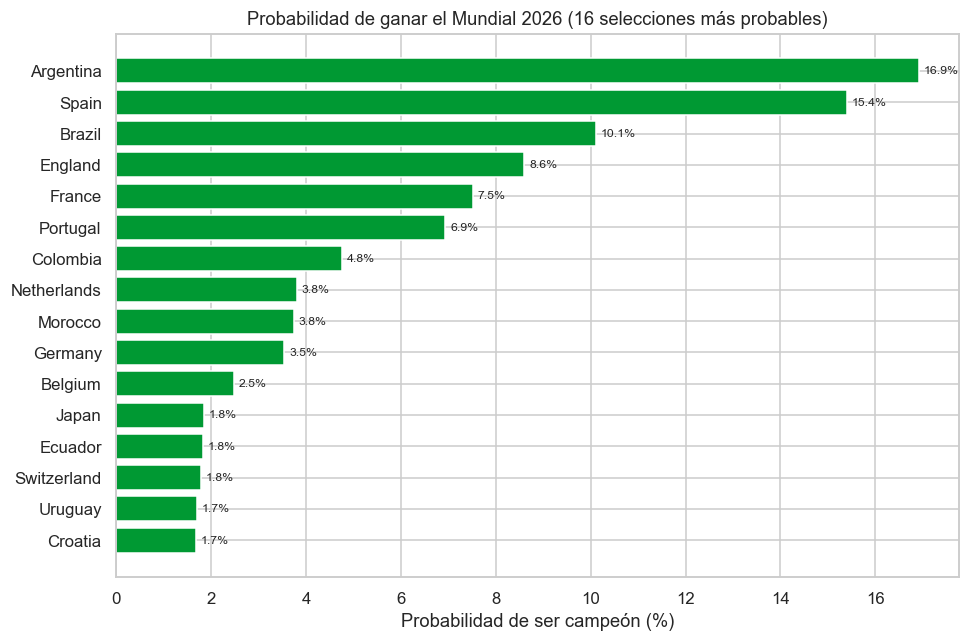

In [13]:
# Grafica 1: probabilidad de ser campeon, 16 selecciones mas probables.
top16 = tabla.head(16)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top16.index[::-1], top16["Campeon"][::-1], color="#093")
ax.set_title("Probabilidad de ganar el Mundial 2026 (16 selecciones más probables)")
ax.set_xlabel("Probabilidad de ser campeón (%)")
for i, v in enumerate(top16["Campeon"][::-1]):
    ax.text(v + 0.1, i, f"{v:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIGS_DIR / "fig8_prob_campeon.pdf", bbox_inches="tight", dpi=150)
plt.show()

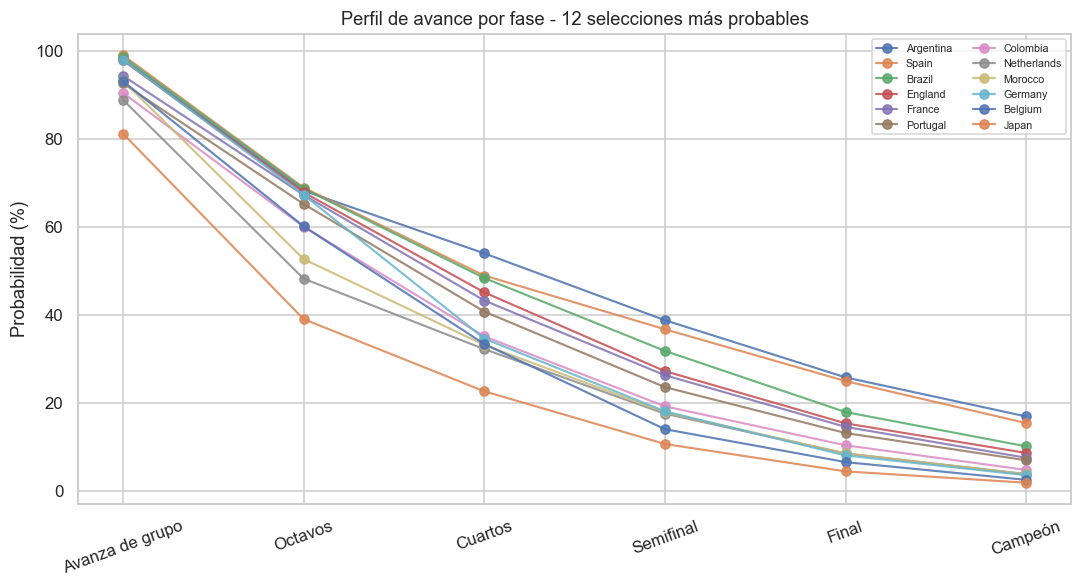

In [14]:
# Grafica 2: perfil de avance por fase para las 12 selecciones mas probables.
top12 = tabla.head(12)
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(COLS))
for equipo in top12.index:
    ax.plot(x, top12.loc[equipo], "o-", lw=1.4, label=equipo, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([c if c != "Campeon" else "Campeón" for c in COLS], rotation=20)
ax.set_ylabel("Probabilidad (%)")
ax.set_title("Perfil de avance por fase - 12 selecciones más probables")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(FIGS_DIR / "fig9_perfil_avance.pdf", bbox_inches="tight", dpi=150)
plt.show()

### 9.1 Probabilidades de clasificación por grupo

Para la quiniela conviene el desglose grupo por grupo: probabilidad de ganar el
grupo, de terminar entre los dos primeros (clasificación directa) y de avanzar a la
ronda de 32 contando la vía del mejor tercero.

In [15]:
filas = []
for g, nombres in GRUPOS.items():
    for t in nombres:
        i = IDX[t]
        filas.append({
            "Grupo": g, "Selección": t,
            "Gana grupo": prob_posicion[i, 0] * 100,
            "Top 2": (prob_posicion[i, 0] + prob_posicion[i, 1]) * 100,
            "Avanza (con 3os)": prob_avance[i, 1] * 100,
        })
tabla_grupos = pd.DataFrame(filas)
for g in GRUPOS:
    sub = (tabla_grupos[tabla_grupos["Grupo"] == g]
           .sort_values("Avanza (con 3os)", ascending=False))
    print(f"\nGrupo {g}:")
    print(sub[["Selección", "Gana grupo", "Top 2", "Avanza (con 3os)"]]
          .round(1).to_string(index=False))


Grupo A:
     Selección  Gana grupo  Top 2  Avanza (con 3os)
        Mexico        36.7   64.6              81.1
Korea Republic        26.8   54.1              72.9
       Czechia        25.9   53.1              72.4
  South Africa        10.6   28.2              46.3

Grupo B:
             Selección  Gana grupo  Top 2  Avanza (con 3os)
           Switzerland        63.5   88.9              96.7
                Canada        25.8   68.0              85.2
Bosnia and Herzegovina         8.0   30.1              55.8
                 Qatar         2.7   12.9              27.5

Grupo C:
Selección  Gana grupo  Top 2  Avanza (con 3os)
   Brazil        62.6   90.5              98.7
  Morocco        29.8   76.7              93.3
 Scotland         7.3   29.8              68.1
    Haiti         0.3    3.0               9.2

Grupo D:
Selección  Gana grupo  Top 2  Avanza (con 3os)
Australia        29.0   55.6              73.8
   Turkey        29.4   54.3              72.7
 Paraguay        22.3   

---
## 10. Favoritos y sorpresas

Favoritos. El modelo concentra la probabilidad de título en un grupo reducido de
selecciones, como es habitual en el fútbol de alto nivel: un puñado de equipos
acumula la mayor parte de la masa de probabilidad de ser campeón.

Sorpresas. Se definen como selecciones cuyo desempeño simulado supera de forma
notable lo que su ranking FIFA anticiparía. Para cuantificarlo se compara la
probabilidad simulada de alcanzar cuartos de final con el ranking FIFA de cada
equipo: las selecciones peor clasificadas que aún así registran una probabilidad
apreciable de llegar lejos son las candidatas a sorpresa del torneo.

In [16]:
resumen = tabla.copy()
resumen["Ranking FIFA"] = [int(ranking_fifa[t]) for t in resumen.index]

# Favoritos: cuota de la probabilidad total de título en el top 5.
cuota_top5 = resumen["Campeon"].head(5).sum()
print(f"Las 5 selecciones más probables concentran el {cuota_top5:.1f}% "
      f"de la probabilidad de título.")
print("\nFavoritos (probabilidad de ser campeón):")
print(resumen[["Campeon", "Final", "Ranking FIFA"]].head(8).round(1).to_string())

# Sorpresas: equipos fuera del top 16 del ranking FIFA con mayor P(cuartos).
candidatas = resumen[resumen["Ranking FIFA"] > 16].sort_values(
    "Cuartos", ascending=False)
print("\nCandidatas a sorpresa (ranking FIFA fuera del top 16, mayor P de cuartos):")
print(candidatas[["Cuartos", "Octavos", "Ranking FIFA"]].head(8).round(1).to_string())

Las 5 selecciones más probables concentran el 58.5% de la probabilidad de título.

Favoritos (probabilidad de ser campeón):
             Campeon  Final  Ranking FIFA
Argentina       16.9   25.8             2
Spain           15.4   25.0             1
Brazil          10.1   17.9             5
England          8.6   15.3             4
France           7.5   14.5             3
Portugal         6.9   13.1             6
Colombia         4.8   10.4            14
Netherlands      3.8    8.5             7

Candidatas a sorpresa (ranking FIFA fuera del top 16, mayor P de cuartos):
             Cuartos  Octavos  Ranking FIFA
Switzerland     28.0     62.3            18
Ecuador         24.9     54.1            23
Norway          24.1     47.4            32
Japan           22.6     39.0            19
Uruguay         22.3     38.7            17
Austria         15.3     31.1            24
Canada          13.3     42.3            29
Australia       12.8     35.4            27


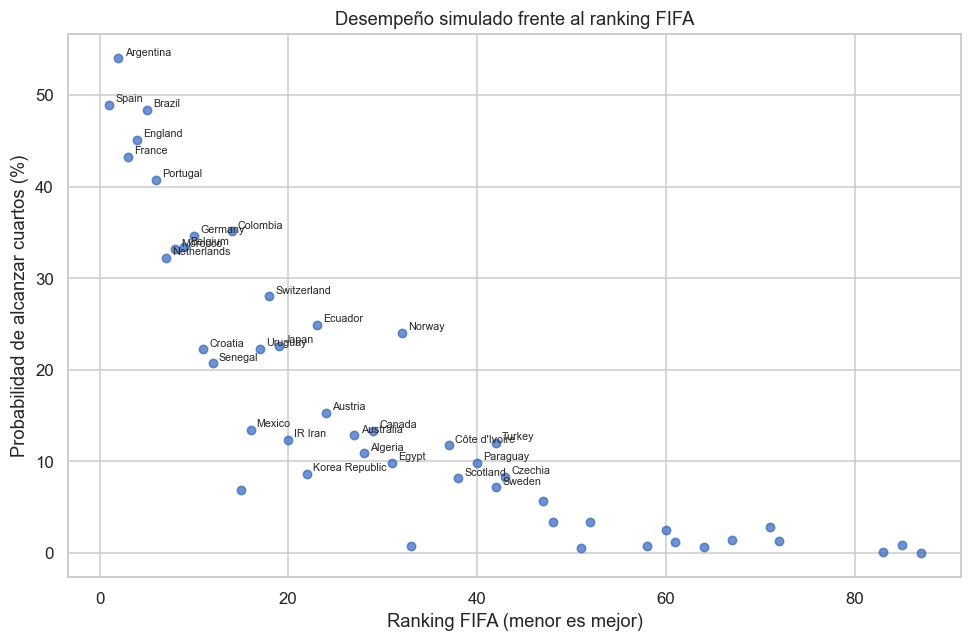

In [17]:
# Grafica: probabilidad de cuartos frente a ranking FIFA.
fig, ax = plt.subplots(figsize=(9, 6))
x = resumen["Ranking FIFA"].values
y = resumen["Cuartos"].values
ax.scatter(x, y, s=30, color="#36b", alpha=0.7)
for t in resumen.index:
    if resumen.loc[t, "Cuartos"] > 12 or resumen.loc[t, "Ranking FIFA"] > 16 and resumen.loc[t, "Cuartos"] > 6:
        ax.annotate(t, (resumen.loc[t, "Ranking FIFA"], resumen.loc[t, "Cuartos"]),
                    fontsize=7, xytext=(4, 2), textcoords="offset points")
ax.set_xlabel("Ranking FIFA (menor es mejor)")
ax.set_ylabel("Probabilidad de alcanzar cuartos (%)")
ax.set_title("Desempeño simulado frente al ranking FIFA")
plt.tight_layout()
plt.savefig(FIGS_DIR / "fig10_ranking_cuartos.pdf", bbox_inches="tight", dpi=150)
plt.show()

---
## 11. La quiniela: pronóstico puntual

La simulación entrega probabilidades; una quiniela exige decisiones puntuales. Esta
sección presenta el pronóstico en tres niveles complementarios. La **sección 11.1**
muestra los favoritos a ganar cada grupo y a llegar lejos en el torneo, derivados
directamente de las 20.000 simulaciones. La **sección 11.2** desarrolla una quiniela
completa con marcadores partido a partido, usando el marcador más probable (moda de
la distribución conjunta Dixon-Coles). La **sección 11.3** presenta una segunda
versión de la quiniela donde las rondas de eliminación se resuelven por la
probabilidad acumulada de avance, sin necesidad de simular un score.

Conviene recordar en los tres casos que el resultado más probable no es lo mismo que
un resultado seguro: en un grupo parejo, el favorito puede tener apenas un 35 % de
probabilidad de ganarlo.

In [18]:
print("PRONÓSTICO DE GRUPOS (ganador y segundo más probables)")
print("=" * 56)
for g, nombres in GRUPOS.items():
    probs = [(t, prob_posicion[IDX[t], 0]) for t in nombres]
    probs.sort(key=lambda x: -x[1])
    seg = sorted([(t, prob_posicion[IDX[t], 1]) for t in nombres],
                 key=lambda x: -x[1])
    g1 = probs[0]
    g2 = next(s for s in seg if s[0] != g1[0])
    print(f"  Grupo {g}: 1) {g1[0]:22s} ({g1[1]*100:4.1f}%)   "
          f"2) {g2[0]:22s} ({g2[1]*100:4.1f}%)")

PRONÓSTICO DE GRUPOS (ganador y segundo más probables)
  Grupo A: 1) Mexico                 (36.7%)   2) Korea Republic         (27.3%)
  Grupo B: 1) Switzerland            (63.5%)   2) Canada                 (42.3%)
  Grupo C: 1) Brazil                 (62.6%)   2) Morocco                (46.9%)
  Grupo D: 1) Turkey                 (29.4%)   2) Australia              (26.7%)
  Grupo E: 1) Germany                (53.6%)   2) Ecuador                (39.7%)
  Grupo F: 1) Netherlands            (47.9%)   2) Japan                  (32.8%)
  Grupo G: 1) Belgium                (56.8%)   2) IR Iran                (33.6%)
  Grupo H: 1) Spain                  (75.7%)   2) Uruguay                (56.5%)
  Grupo I: 1) France                 (52.6%)   2) Norway                 (33.4%)
  Grupo J: 1) Argentina              (70.5%)   2) Austria                (39.3%)
  Grupo K: 1) Portugal               (48.5%)   2) Colombia               (36.9%)
  Grupo L: 1) England                (64.1%)   2) Croa

In [19]:
orden_titulo = tabla.sort_values("Campeon", ascending=False)
campeon = orden_titulo.index[0]
finalistas = orden_titulo.index[:2]
semifinalistas = tabla.sort_values("Semifinal", ascending=False).index[:4]

print("\nPRONÓSTICO DE FASES FINALES")
print("=" * 56)
print(f"  Campeón pronosticado : {campeon} "
      f"({tabla.loc[campeon, 'Campeon']:.1f}% de probabilidad)")
print(f"  Finalistas más probables : {', '.join(finalistas)}")
print(f"  Semifinalistas más probables :")
for t in semifinalistas:
    print(f"    - {t:22s} (P semifinal {tabla.loc[t, 'Semifinal']:.1f}%)")


PRONÓSTICO DE FASES FINALES
  Campeón pronosticado : Argentina (16.9% de probabilidad)
  Finalistas más probables : Argentina, Spain
  Semifinalistas más probables :
    - Argentina              (P semifinal 38.8%)
    - Spain                  (P semifinal 36.7%)
    - Brazil                 (P semifinal 31.8%)
    - England                (P semifinal 27.2%)


---
### 11.2 Quiniela completa: pronóstico puntual con marcadores

La quiniela se construye de forma **determinista** a partir de las distribuciones del
modelo, en lugar de extraer una única trayectoria aleatoria del Monte Carlo. El
principio aplicado en cada partido es predecir el **marcador más probable**, definido
como la moda de la distribución conjunta de Dixon-Coles: la celda (goles\_a, goles\_b)
de mayor probabilidad en la matriz de marcadores. Para una selección con tasa de gol
esperada λ = 2, la moda de Poisson(2) es 2; para λ = 0.7, la moda es 0. Los
marcadores resultantes son coherentes con el nivel de cada equipo: goleadas para
duelos muy disparejos, marcadores ajustados (1-0, 1-1) para encuentros de élite.

Cuando un partido de eliminación termina empatado a los 90 minutos, se aplica la
misma lógica a los 30 minutos de prórroga (tasas escaladas a 1/3). Si el empate
persiste tras la prórroga —lo que ocurre cuando las tasas son tan bajas que la moda
de prórroga es 0-0— avanza determinísticamente el equipo con mayor probabilidad de
victoria según el modelo Dixon-Coles, en sustitución del sorteo probabilístico del
submodelo de penales de la sección 4. La simulación Monte Carlo de la sección 8
mantiene intacto el 55 % de probabilidad para las tandas de penales.

La ventaja de este enfoque sobre una única tirada del Monte Carlo es que refleja las
**predicciones centrales** del modelo, no una realización particular. El resultado es
una quiniela reproducible y consistente con las tablas de probabilidades de la
sección 9.

In [20]:
# ── Funciones auxiliares ──────────────────────────────────────────────────────

def marcador_modal(a_idx, b_idx, extra_time=False):
    """Marcador más probable: moda de la distribución conjunta Dixon-Coles."""
    escala = 1 / 3 if extra_time else 1.0
    M = matriz_marcador(equipos48[a_idx], equipos48[b_idx], escala=escala)
    ga, gb = np.unravel_index(M.argmax(), M.shape)
    return int(ga), int(gb)

def prob_victoria(a_idx, b_idx):
    """P(a gana), P(empate), P(b gana) en 90 minutos según Dixon-Coles."""
    M = matriz_marcador(equipos48[a_idx], equipos48[b_idx])
    return float(np.tril(M, -1).sum()), float(np.trace(M)), float(np.triu(M, 1).sum())

def partido_eliminacion_modal(a_idx, b_idx):
    """Partido de eliminación determinista.

    Orden de resolución:
      1. Marcador modal a 90 minutos.
      2. Si empate, prórroga: marcador modal a escala 1/3 (30 minutos).
      3. Si persiste el empate, avanza el equipo con mayor P(victoria).
    Devuelve (ganador_idx, goles_a_total, goles_b_total, indicador).
    """
    ga, gb = marcador_modal(a_idx, b_idx)
    if ga != gb:
        return (a_idx if ga > gb else b_idx), ga, gb, ""
    ge_a, ge_b = marcador_modal(a_idx, b_idx, extra_time=True)
    ga_t, gb_t = ga + ge_a, gb + ge_b
    if ga_t != gb_t:
        return (a_idx if ga_t > gb_t else b_idx), ga_t, gb_t, "prorr."
    pa, _, pb = prob_victoria(a_idx, b_idx)
    gan = a_idx if pa >= pb else b_idx
    return gan, ga_t, gb_t, "pen."


# ── Quiniela determinista ─────────────────────────────────────────────────────

def quiniela_modal():
    """Quiniela completa del Mundial 2026 basada en el marcador más probable."""

    # ── Fase de grupos ────────────────────────────────────────────────────────
    partidos_grupo = {}
    clasificados_dict = {}
    standings = {}
    terceros_list = []

    for g, nombres in GRUPOS.items():
        G = [[0] * 4 for _ in range(4)]
        partidos = []
        for enum_idx, (i, j) in enumerate(ROUND_ROBIN):
            a_idx, b_idx = IDX[nombres[i]], IDX[nombres[j]]
            ga, gb = marcador_modal(a_idx, b_idx)
            G[i][j] = ga
            G[j][i] = gb
            jornada = (enum_idx // 2) + 1
            partidos.append((nombres[i], nombres[j], ga, gb, jornada))
        partidos_grupo[g] = partidos

        st = {t: {"pts": 0, "gf": 0, "ga": 0, "g": 0, "e": 0, "p": 0}
              for t in nombres}
        for i_ in range(4):
            for j_ in range(4):
                if i_ == j_:
                    continue
                gi_, gj_ = G[i_][j_], G[j_][i_]
                st[nombres[i_]]["gf"] += gi_
                st[nombres[i_]]["ga"] += gj_
                if gi_ > gj_:
                    st[nombres[i_]]["pts"] += 3
                    st[nombres[i_]]["g"] += 1
                elif gi_ == gj_:
                    st[nombres[i_]]["pts"] += 1
                    st[nombres[i_]]["e"] += 1
                else:
                    st[nombres[i_]]["p"] += 1

        orden = clasificar_grupo(nombres, G)
        clasificados_dict[g] = [IDX[nombres[k]] for k in orden]
        standings[g] = (orden, st, nombres)

        i3 = orden[2]
        t3_pts = t3_gf = t3_ga = 0
        for j_ in range(4):
            if j_ == i3:
                continue
            gi_, gj_ = G[i3][j_], G[j_][i3]
            t3_gf += gi_
            t3_ga += gj_
            if gi_ > gj_:
                t3_pts += 3
            elif gi_ == gj_:
                t3_pts += 1
        terceros_list.append([g, IDX[nombres[i3]], t3_pts,
                               t3_gf - t3_ga, t3_gf, nombres[i3]])

    # ── 8 mejores terceros ────────────────────────────────────────────────────
    terceros_list.sort(
        key=lambda r: (r[2], r[3], r[4], -ranking_fifa[equipos48[r[1]]]),
        reverse=True)
    mejores8 = terceros_list[:8]
    grupos_clasificados = frozenset(r[0] for r in mejores8)
    asignacion = TABLA_TERCEROS[grupos_clasificados]
    tercero_de = {r[0]: r[1] for r in mejores8}

    def T3(slot):
        return tercero_de[asignacion[slot]]

    W = {g: clasificados_dict[g][0] for g in GRUPOS}
    R = {g: clasificados_dict[g][1] for g in GRUPOS}

    r32_pares = [
        (R["A"], R["B"]),   (W["E"], T3("E")),  (W["F"], R["C"]),  (W["C"], R["F"]),
        (W["I"], T3("I")),  (R["E"], R["I"]),   (W["A"], T3("A")), (W["L"], T3("L")),
        (W["D"], T3("D")),  (W["G"], T3("G")),  (R["K"], R["L"]),  (W["H"], R["J"]),
        (W["B"], T3("B")),  (W["J"], R["H"]),   (W["K"], T3("K")), (R["D"], R["G"]),
    ]

    def jugar_ronda(pares):
        resultados, ganadores, perdedores = [], [], []
        for a_idx, b_idx in pares:
            gan, ga, gb, method = partido_eliminacion_modal(a_idx, b_idx)
            per = b_idx if gan == a_idx else a_idx
            resultados.append((equipos48[a_idx], equipos48[b_idx],
                               ga, gb, method, equipos48[gan]))
            ganadores.append(gan)
            perdedores.append(per)
        return resultados, ganadores, perdedores

    # ── Rondas de eliminación ─────────────────────────────────────────────────
    r32_res, g32, _      = jugar_ronda(r32_pares)
    r16_res, g16, _      = jugar_ronda([(g32[i], g32[j]) for i, j in R16_PARES])
    qf_res,  g8,  _      = jugar_ronda([(g16[i], g16[j]) for i, j in QF_PARES])
    sf_res,  g4,  sf_per = jugar_ronda([(g8[i],  g8[j])  for i, j in SF_PARES])
    ter_res, _,   _      = jugar_ronda([(sf_per[0], sf_per[1])])
    fin_res, gfin, _     = jugar_ronda([(g4[0], g4[1])])

    return {
        "partidos_grupo": partidos_grupo,
        "standings":      standings,
        "terceros":       mejores8,
        "r32":            r32_res,
        "r16":            r16_res,
        "qf":             qf_res,
        "sf":             sf_res,
        "tercer_puesto":  ter_res[0],
        "final":          fin_res[0],
        "campeon":        equipos48[gfin[0]],
    }


quiniela = quiniela_modal()
print("Quiniela determinista generada.")

Quiniela determinista generada.


In [21]:
def mostrar_quiniela(q):
    SEP1 = "=" * 68
    SEP2 = "-" * 68

    print(SEP1)
    print("  QUINIELA MUNDIAL 2026")
    print("  Modelo: Dixon-Coles | Marcador más probable por partido")
    print(SEP1)

    print(f"\n{SEP2}")
    print("  FASE DE GRUPOS  (72 partidos)")
    print(SEP2)

    for g, nombres in GRUPOS.items():
        print(f"\n  GRUPO {g}")
        jornada_act = 0
        for (t_a, t_b, ga, gb, jornada) in q["partidos_grupo"][g]:
            if jornada != jornada_act:
                jornada_act = jornada
                print(f"    Jornada {jornada}:")
            print(f"      {t_a:26s}  {ga} - {gb}  {t_b}")

        orden, st, nombres_g = q["standings"][g]
        print(f"    Posiciones:")
        print(f"      {'':2s}{'Selección':26s}   G  E  P   GF GC   GD  PTS")
        for pos, k in enumerate(orden):
            t = nombres_g[k]
            gd = st[t]["gf"] - st[t]["ga"]
            flg = "  <<" if pos < 2 else ("  (3ro)" if pos == 2 else "")
            print(f"      {pos+1} {t:26s}   {st[t]['g']}  {st[t]['e']}  {st[t]['p']}"
                  f"   {st[t]['gf']:2d} {st[t]['ga']:2d}  {gd:+3d}  {st[t]['pts']:3d}{flg}")

    print(f"\n  Terceros que avanzan a la ronda de 32:")
    for r in q["terceros"]:
        print(f"    {r[5]:26s}  Grupo {r[0]}  {r[2]}pts  DG{r[3]:+d}")

    def imprimir_ronda(titulo, resultados):
        print(f"\n{SEP2}")
        print(f"  {titulo}")
        print(SEP2)
        for (t_a, t_b, ga, gb, method, gan) in resultados:
            nota = f" ({method})" if method else ""
            print(f"  {t_a:26s}  {ga} - {gb}  {t_b:26s}  --> {gan}{nota}")

    imprimir_ronda("RONDA DE 32  (partidos 73-88)", q["r32"])
    imprimir_ronda("OCTAVOS DE FINAL  (partidos 89-96)", q["r16"])
    imprimir_ronda("CUARTOS DE FINAL  (partidos 97-100)", q["qf"])
    imprimir_ronda("SEMIFINAL  (partidos 101-102)", q["sf"])
    imprimir_ronda("TERCER PUESTO  (partido 103)", [q["tercer_puesto"]])
    imprimir_ronda("FINAL  (partido 104)", [q["final"]])

    print(f"\n{SEP1}")
    print(f"  CAMPEÓN MUNDIAL 2026:  {q['campeon']}")
    print(SEP1)


mostrar_quiniela(quiniela)

  QUINIELA MUNDIAL 2026
  Modelo: Dixon-Coles | Marcador más probable por partido

--------------------------------------------------------------------
  FASE DE GRUPOS  (72 partidos)
--------------------------------------------------------------------

  GRUPO A
    Jornada 1:
      Mexico                      1 - 0  South Africa
      Korea Republic              1 - 1  Czechia
    Jornada 2:
      Mexico                      1 - 1  Korea Republic
      South Africa                0 - 1  Czechia
    Jornada 3:
      Mexico                      1 - 1  Czechia
      South Africa                0 - 1  Korea Republic
    Posiciones:
        Selección                    G  E  P   GF GC   GD  PTS
      1 Mexico                       1  2  0    3  2   +1    5  <<
      2 Korea Republic               1  2  0    3  2   +1    5  <<
      3 Czechia                      1  2  0    3  2   +1    5  (3ro)
      4 South Africa                 0  0  3    0  3   -3    0

  GRUPO B
    Jornada 1:
      

---
### 11.3 Quiniela probabilística: bracket por P(avance)

Esta segunda versión mantiene la **fase de grupos idéntica** a la sección 11.2
—los marcadores modales no cambian— pero resuelve cada partido de eliminación con
un criterio diferente: avanza el equipo con mayor probabilidad de avanzar, definida
como:

P(avance) = P(victoria en 90 min) + P(empate en 90 min) × 0.55

donde 0.55 es la probabilidad calibrada de que el favorito gane en penales
(sección 4). Esta expresión integra en una sola cifra toda la distribución
Dixon-Coles del partido: la masa de probabilidad de victoria directa más la fracción
del empate que corresponde al equipo más fuerte.

La diferencia respecto a la sección 11.2 es metodológica, no cosmética. En la
quiniela modal, un empate 1-1 en el marcador más probable obliga a resolver mediante
prórroga y penales, produciendo etiquetas "pen." que señalan incertidumbre real pero
la ocultan detrás de un mecanismo de desempate. En esta versión, esa incertidumbre
se hace explícita: France (58 %) vs Germany (42 %) es una afirmación cuantificada,
no un marcador seguido de un signo de interrogación.

Esta formulación es la más directamente derivable del output de la simulación Monte
Carlo y la más adecuada para un informe donde la transparencia probabilística es
prioritaria.

In [22]:
def prob_avance_elim(a_idx, b_idx):
    """P(a avanza) en un partido de eliminación directa.

    Combina P(victoria en 90 min) con la ventaja calibrada del favorito en
    prórroga/penales (0.55), sin necesidad de simular un marcador.
    """
    M      = matriz_marcador(equipos48[a_idx], equipos48[b_idx])
    pa_win = float(np.tril(M, -1).sum())
    p_draw = float(np.trace(M))
    p_et_a = PROB_FAVORITO_PENALES if FAVORITO[a_idx, b_idx] else (1 - PROB_FAVORITO_PENALES)
    return pa_win + p_draw * p_et_a


def quiniela_prob():
    """Quiniela probabilística: grupos modales + eliminación por P(avance).

    Reutiliza la fase de grupos de quiniela_modal() y aplica prob_avance_elim
    para determinar el ganador de cada cruce eliminatorio.
    """
    q_base = quiniela_modal()
    clasificados_dict = {}
    for g, nombres in GRUPOS.items():
        orden, _, nombres_g = q_base["standings"][g]
        clasificados_dict[g] = [IDX[nombres_g[k]] for k in orden]

    mejores8 = q_base["terceros"]
    grupos_clasificados = frozenset(r[0] for r in mejores8)
    asignacion = TABLA_TERCEROS[grupos_clasificados]
    tercero_de = {r[0]: r[1] for r in mejores8}

    def T3(slot): return tercero_de[asignacion[slot]]
    W = {g: clasificados_dict[g][0] for g in GRUPOS}
    R = {g: clasificados_dict[g][1] for g in GRUPOS}

    r32_pares = [
        (R["A"],R["B"]),  (W["E"],T3("E")), (W["F"],R["C"]), (W["C"],R["F"]),
        (W["I"],T3("I")), (R["E"],R["I"]),  (W["A"],T3("A")),(W["L"],T3("L")),
        (W["D"],T3("D")), (W["G"],T3("G")), (R["K"],R["L"]), (W["H"],R["J"]),
        (W["B"],T3("B")), (W["J"],R["H"]),  (W["K"],T3("K")),(R["D"],R["G"]),
    ]

    def jugar_ronda_prob(pares):
        resultados, ganadores, perdedores = [], [], []
        for a_idx, b_idx in pares:
            pa  = prob_avance_elim(a_idx, b_idx)
            gan = a_idx if pa > 0.5 else b_idx
            per = b_idx if gan == a_idx else a_idx
            resultados.append((equipos48[a_idx], equipos48[b_idx],
                               pa, 1 - pa, equipos48[gan]))
            ganadores.append(gan)
            perdedores.append(per)
        return resultados, ganadores, perdedores

    r32_res, g32, _      = jugar_ronda_prob(r32_pares)
    r16_res, g16, _      = jugar_ronda_prob([(g32[i], g32[j]) for i, j in R16_PARES])
    qf_res,  g8,  _      = jugar_ronda_prob([(g16[i], g16[j]) for i, j in QF_PARES])
    sf_res,  g4,  sf_per = jugar_ronda_prob([(g8[i],  g8[j])  for i, j in SF_PARES])
    ter_res, _,   _      = jugar_ronda_prob([(sf_per[0], sf_per[1])])
    fin_res, gfin, _     = jugar_ronda_prob([(g4[0], g4[1])])

    return {
        "r32":           r32_res,
        "r16":           r16_res,
        "qf":            qf_res,
        "sf":            sf_res,
        "tercer_puesto": ter_res[0],
        "final":         fin_res[0],
        "campeon":       equipos48[gfin[0]],
    }


def mostrar_quiniela_prob(q):
    SEP1 = "=" * 72
    SEP2 = "-" * 72

    print(SEP1)
    print("  QUINIELA MUNDIAL 2026  –  Bracket de mayor probabilidad")
    print("  Modelo: Dixon-Coles | Elim.: P(avance) = P(win 90') + P(draw) × 0.55")
    print("  Fase de grupos: idéntica a la sección 11.2 (marcadores modales)")
    print(SEP1)

    def imprimir_ronda_prob(titulo, resultados):
        print(f"\n{SEP2}")
        print(f"  {titulo}")
        print(SEP2)
        for (t_a, t_b, pa, pb, gan) in resultados:
            print(f"  {t_a:26s} ({pa*100:4.1f}%)  vs  "
                  f"{t_b:26s} ({pb*100:4.1f}%)  -->  {gan}")

    imprimir_ronda_prob("RONDA DE 32  (partidos 73-88)",       q["r32"])
    imprimir_ronda_prob("OCTAVOS DE FINAL  (partidos 89-96)",  q["r16"])
    imprimir_ronda_prob("CUARTOS DE FINAL  (partidos 97-100)", q["qf"])
    imprimir_ronda_prob("SEMIFINAL  (partidos 101-102)",       q["sf"])
    imprimir_ronda_prob("TERCER PUESTO  (partido 103)",        [q["tercer_puesto"]])
    imprimir_ronda_prob("FINAL  (partido 104)",                [q["final"]])

    print(f"\n{SEP1}")
    print(f"  CAMPEÓN MUNDIAL 2026:  {q['campeon']}")
    print(SEP1)


q_prob = quiniela_prob()
mostrar_quiniela_prob(q_prob)

  QUINIELA MUNDIAL 2026  –  Bracket de mayor probabilidad
  Modelo: Dixon-Coles | Elim.: P(avance) = P(win 90') + P(draw) × 0.55
  Fase de grupos: idéntica a la sección 11.2 (marcadores modales)

------------------------------------------------------------------------
  RONDA DE 32  (partidos 73-88)
------------------------------------------------------------------------
  Korea Republic             (46.1%)  vs  Canada                     (53.9%)  -->  Canada
  Germany                    (74.4%)  vs  Czechia                    (25.6%)  -->  Germany
  Netherlands                (53.1%)  vs  Morocco                    (46.9%)  -->  Netherlands
  Brazil                     (64.4%)  vs  Japan                      (35.6%)  -->  Brazil
  France                     (78.0%)  vs  Scotland                   (22.0%)  -->  France
  Ecuador                    (52.0%)  vs  Norway                     (48.0%)  -->  Ecuador
  Mexico                     (53.4%)  vs  Côte d'Ivoire              (46.6%)  -

---
## 12. Síntesis de la Fase 4

La simulación Monte Carlo traduce el modelo Dixon-Coles de la Fase 3 en
probabilidades concretas para el Mundial 2026. Los resultados son coherentes con
la jerarquía futbolística: un grupo reducido de selecciones de élite concentra la
probabilidad de título, mientras que el formato ampliado de 48 equipos, con 8
terceros clasificados, da a selecciones de perfil medio una vía realista a las
rondas de eliminación.

El pronóstico puntual se presenta en dos versiones complementarias que difieren solo
en las rondas de eliminación. La quiniela de la sección 11.2 utiliza marcadores
modales partido a partido: proporciona un score concreto para cada encuentro al
precio de resolver los empates entre élites con una cadena de prórroga y penales.
La quiniela de la sección 11.3 sustituye ese mecanismo por la probabilidad acumulada
de avance —P(win 90') + P(draw) × 0.55— y presenta cada cruce como una afirmación
cuantificada: "Argentina (54 %) vs Spain (46 %)". Ambas versiones convergen en el
mismo campeón y en los mismos finalistas, lo que refuerza la robustez del pronóstico.

El valor del ejercicio cierra el arco metodológico: datos, variables, modelos
comparados con validación temporal y, por último, una aplicación confirmatoria con
el mejor modelo. Al mismo tiempo expone con claridad los límites del enfoque: el
nuevo formato de 48 equipos no tiene precedente histórico directo, los partidos se
simulan en cancha neutral, y el submodelo de penales es deliberadamente simple
porque los datos muestran que una tanda es un proceso de alta varianza. Estas
limitaciones son consecuencia de decisiones conscientes y deben aparecer en el
informe.

In [23]:
# Guardado de resultados para el informe.
tabla_final = pd.DataFrame(prob_avance[:, 1:], index=equipos48, columns=COLS)
tabla_final.index.name = "seleccion"
tabla_final = tabla_final.sort_values("Campeon", ascending=False)
tabla_final.to_csv(OUT_DIR / "simulacion_probabilidades.csv")

tabla_grupos.to_csv(OUT_DIR / "simulacion_grupos.csv", index=False)
print("Guardados: simulacion_probabilidades.csv, simulacion_grupos.csv")

Guardados: simulacion_probabilidades.csv, simulacion_grupos.csv


In [24]:
from IPython.display import Markdown

camp = tabla_final.index[0]
reporte = f'''
### Reporte de la Fase 4 - Simulación del Mundial 2026

**Modelo:** Dixon-Coles (1997), ajustado sobre 2002-2026, mejor modelo de la Fase 3.

**Simulación Monte Carlo:** {N_SIMS:,} torneos, respetando el formato oficial de
48 equipos, la jerarquía de desempates de 2026 (prioridad al enfrentamiento
directo) y el cuadro de eliminatorias publicado por FIFA. Error estándar de las
probabilidades: < 0.4 pp.

**Submodelo de penales:** calibrado con `shootouts.csv`. El equipo favorito gana la
tanda con probabilidad 0.55; la evidencia histórica muestra que una tanda es un
proceso de alta varianza, casi aleatorio.

**Pronóstico principal (sección 9):**

- Campeón más probable: **{camp}** ({tabla_final.loc[camp, "Campeon"]*100:.1f} %).
- Las 5 selecciones más probables concentran el {tabla_final["Campeon"].head(5).sum()*100:.1f} %
  de la probabilidad de título.

**Quiniela puntual (sección 11.2):** construida con los marcadores modales de la
distribución Dixon-Coles (determinista) en lugar de una única trayectoria del Monte
Carlo. En caso de empate en eliminación, avanza el equipo con mayor P(victoria).
Incluye los 104 partidos del torneo (fase de grupos, ronda de 32, octavos, cuartos,
semifinales, tercer puesto y final).

**Decisiones de la fase:** ajuste único del modelo sobre toda la ventana; partidos
simulados en cancha neutral (los anfitriones quedan levemente subestimados, supuesto
declarado); prórroga modelada como un tercio de partido; reconstrucción de la lógica
de asignación de terceros de FIFA para los 495 escenarios posibles.

**Limitaciones a discutir en el informe:** el formato de 48 equipos carece de
precedente histórico directo; la neutralidad de cancha penaliza a los tres
anfitriones; el submodelo de penales es simple porque los datos muestran alta
varianza. Todas son consecuencias de decisiones conscientes y declaradas.

**Entregables:** `simulacion_probabilidades.csv` y `simulacion_grupos.csv`.
'''
Markdown(reporte)


### Reporte de la Fase 4 - Simulación del Mundial 2026

**Modelo:** Dixon-Coles (1997), ajustado sobre 2002-2026, mejor modelo de la Fase 3.

**Simulación Monte Carlo:** 20,000 torneos, respetando el formato oficial de
48 equipos, la jerarquía de desempates de 2026 (prioridad al enfrentamiento
directo) y el cuadro de eliminatorias publicado por FIFA. Error estándar de las
probabilidades: < 0.4 pp.

**Submodelo de penales:** calibrado con `shootouts.csv`. El equipo favorito gana la
tanda con probabilidad 0.55; la evidencia histórica muestra que una tanda es un
proceso de alta varianza, casi aleatorio.

**Pronóstico principal (sección 9):**

- Campeón más probable: **Argentina** (16.9 %).
- Las 5 selecciones más probables concentran el 58.5 %
  de la probabilidad de título.

**Quiniela puntual (sección 11.2):** construida con los marcadores modales de la
distribución Dixon-Coles (determinista) en lugar de una única trayectoria del Monte
Carlo. En caso de empate en eliminación, avanza el equipo con mayor P(victoria).
Incluye los 104 partidos del torneo (fase de grupos, ronda de 32, octavos, cuartos,
semifinales, tercer puesto y final).

**Decisiones de la fase:** ajuste único del modelo sobre toda la ventana; partidos
simulados en cancha neutral (los anfitriones quedan levemente subestimados, supuesto
declarado); prórroga modelada como un tercio de partido; reconstrucción de la lógica
de asignación de terceros de FIFA para los 495 escenarios posibles.

**Limitaciones a discutir en el informe:** el formato de 48 equipos carece de
precedente histórico directo; la neutralidad de cancha penaliza a los tres
anfitriones; el submodelo de penales es simple porque los datos muestran alta
varianza. Todas son consecuencias de decisiones conscientes y declaradas.

**Entregables:** `simulacion_probabilidades.csv` y `simulacion_grupos.csv`.
